In [1]:
pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 10.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ============================================================
# Cell 1 — Install (same stack as bench.ipynb, no torch conflicts)
# Use a FRESH Kaggle GPU session. Internet ON.
# ============================================================
import subprocess, sys

def pipi(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *args]
    print(">>", " ".join(cmd))
    subprocess.check_call(cmd)

pipi("-U", "pip", "wheel")
pipi("shapely", "tqdm", "pillow", "opencv-python-headless", "PyYAML", "lmdb", "pyclipper")

# PaddlePaddle GPU (cu118 wheel — same as bench.ipynb)
try:
    pipi(
        "paddlepaddle-gpu==3.0.0",
        "-i", "https://www.paddlepaddle.org.cn/packages/stable/cu118/",
    )
except subprocess.CalledProcessError:
    print("GPU wheel failed — falling back to CPU paddle (slow but functional)")
    pipi("paddlepaddle")

# langchain stubs needed by paddleocr/paddlex on Kaggle
pipi("langchain-core", "langchain-text-splitters")
pipi("paddleocr")

print("\n Install complete. If 'PDX has already been initialized' appears later, "
      "restart the session and Run All from THIS cell.")

>> /usr/bin/python3 -m pip install -q -U pip wheel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


>> /usr/bin/python3 -m pip install -q shapely tqdm pillow opencv-python-headless PyYAML lmdb pyclipper
>> /usr/bin/python3 -m pip install -q paddlepaddle-gpu==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


>> /usr/bin/python3 -m pip install -q langchain-core langchain-text-splitters
>> /usr/bin/python3 -m pip install -q paddleocr


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires PyYAML<6.1,>=6.0.3, but you have pyyaml 6.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0


 Install complete. If 'PDX has already been initialized' appears later, restart the session and Run All from THIS cell.


In [4]:
# ============================================================
# Cell 2 — Clone PaddleOCR repo (needed for training configs)
# ============================================================
import os, subprocess

REPO_DIR = "/kaggle/working/PaddleOCR"
if not os.path.isdir(REPO_DIR):
    subprocess.check_call(["git", "clone", "--depth", "1",
                           "https://github.com/PaddlePaddle/PaddleOCR.git",
                           REPO_DIR])
    print(" PaddleOCR repo cloned")
else:
    print(" Repo already present")

# Add repo root to path so `tools/train.py` can import ppocr modules
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print("REPO_DIR:", REPO_DIR)

Cloning into '/kaggle/working/PaddleOCR'...


 PaddleOCR repo cloned
REPO_DIR: /kaggle/working/PaddleOCR


In [5]:
# ============================================================
# Cell 3 — Paths & device check
# ============================================================
import os, glob, re
os.environ.setdefault("PADDLE_PDX_EAGER_INIT", "0")

import paddle
import numpy as np

# Reproducibility seed. GPU/Paddle dataloader kernels may still have small
# nondeterminism, but this fixes Python/NumPy/Paddle/Torch RNG starts.
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
paddle.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
except Exception:
    pass
print(f"Seed set to {SEED}")

def _find_vintext_root():
    candidates = [
        "/kaggle/input/datasets/hungkhoi/vietnamese-scene-text-spotting-dataset-vintext/vintext/vintext",
        "/kaggle/input/vietnamese-scene-text-spotting-dataset-vintext/vintext/vintext",
    ]
    for c in candidates:
        if os.path.isdir(os.path.join(c, "test_image")):
            return c
    for base in glob.glob("/kaggle/input/*"):
        tail = os.path.join(base, "vintext", "vintext")
        if os.path.isdir(os.path.join(tail, "test_image")):
            return tail
    return candidates[0]

BASE       = _find_vintext_root()
TRAIN_DIR  = os.path.join(BASE, "train_images")
VAL_DIR    = os.path.join(BASE, "val_image")
TEST_DIR   = os.path.join(BASE, "test_image")
LABEL_DIR  = os.path.join(BASE, "labels")

# E2E working directory (recognition training + metrics)
OUT_DIR    = "/kaggle/working/ppocrv3_e2e_vintext"
os.makedirs(OUT_DIR, exist_ok=True)

# Pretrained detector from ppocrv3_100epochs.ipynb (upload as Kaggle dataset or use working path)
DET_WORK_DIR = "/kaggle/working/ppocrv3_det_vintext"
DET_PTH_CANDIDATES = [
    os.path.join(DET_WORK_DIR, "ppocrv3_mobile_det_vintext.pth"),
    "/kaggle/input/models/doddkaggleancut/ppocrv3-mobile-det-vintext/pytorch/default/1/ppocrv3_mobile_det_vintext.pth",
    "/kaggle/input/ppocrv3-mobile-det-vintext/ppocrv3_mobile_det_vintext.pth",
    "/kaggle/input/ppocrv3-det-vintext/ppocrv3_mobile_det_vintext.pth",
]


def _find_det_pth():
    for p in DET_PTH_CANDIDATES:
        if os.path.isfile(p):
            return p
    for base in glob.glob("/kaggle/input/*"):
        for root, _, files in os.walk(base):
            if "ppocrv3_mobile_det_vintext.pth" in files:
                return os.path.join(root, "ppocrv3_mobile_det_vintext.pth")
    return None

PADDLE_DEVICE = "gpu" if (paddle.device.is_compiled_with_cuda()
                          and paddle.device.cuda.device_count() > 0) else "cpu"
print(f"Paddle device : {PADDLE_DEVICE}")
print(f"BASE          : {BASE}")
print(f"Train images  : {len(glob.glob(os.path.join(TRAIN_DIR, '*.jpg')))}")
print(f"Val images    : {len(glob.glob(os.path.join(VAL_DIR, '*.jpg')))}")
print(f"Test images   : {len(glob.glob(os.path.join(TEST_DIR, '*.jpg')))}")
print(f"E2E OUT_DIR   : {OUT_DIR}")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Seed set to 42
Paddle device : gpu
BASE          : /kaggle/input/datasets/hungkhoi/vietnamese-scene-text-spotting-dataset-vintext/vintext/vintext
Train images  : 1200
Val images    : 300
Test images   : 500
E2E OUT_DIR   : /kaggle/working/ppocrv3_e2e_vintext


In [6]:
!pip install -q rapidfuzz

In [7]:
# ============================================================
# Cell 4 — VinText parsers + crop helpers (E2E protocol)
# ============================================================
import json, unicodedata, math
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
from tqdm import tqdm
from rapidfuzz.distance import Levenshtein
from shapely.geometry import Polygon as _ShapelyPolygon

def parse_annotation(gt_path: str) -> List[Tuple[np.ndarray, str]]:
    records = []
    if not os.path.exists(gt_path):
        return records
    with open(gt_path, encoding="utf-8-sig", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",", 8)
            if len(parts) < 9:
                continue
            try:
                coords = list(map(float, parts[:8]))
            except ValueError:
                continue
            transcript = parts[8].strip()
            pts = np.array(coords, dtype=np.float32).reshape(4, 2)
            records.append((pts, transcript))
    return records


def _img_idx_from_name(name: str):
    m = re.search(r"(\d+)", os.path.basename(name))
    return int(m.group(1)) if m else None


def normalize_for_match(s: str) -> str:
    return unicodedata.normalize("NFD", s).strip()


def order_quad(pts: np.ndarray) -> np.ndarray:
    pts = np.asarray(pts, dtype=np.float32)
    rect = np.zeros((4, 2), dtype=np.float32)
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = pts[:, 1] - pts[:, 0]
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect


def crop_quad(image_bgr: np.ndarray, pts: np.ndarray, target_h: int = 48) -> np.ndarray:
    pts = order_quad(pts.astype(np.float32))
    w1 = np.linalg.norm(pts[1] - pts[0]); w2 = np.linalg.norm(pts[2] - pts[3])
    h1 = np.linalg.norm(pts[3] - pts[0]); h2 = np.linalg.norm(pts[2] - pts[1])
    W = max(int((w1 + w2) / 2), 1); H = max(int((h1 + h2) / 2), 1)
    dst = np.array([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]], dtype=np.float32)
    M = cv2.getPerspectiveTransform(pts, dst)
    crop = cv2.warpPerspective(image_bgr, M, (W, H))
    scale = target_h / max(crop.shape[0], 1)
    new_w = max(int(crop.shape[1] * scale), 1)
    return cv2.resize(crop, (new_w, target_h))


def polygon_iou(p1: np.ndarray, p2: np.ndarray) -> float:
    try:
        a = _ShapelyPolygon(p1); b = _ShapelyPolygon(p2)
        if not a.is_valid: a = a.buffer(0)
        if not b.is_valid: b = b.buffer(0)
        if a.is_empty or b.is_empty:
            return 0.0
        inter = a.intersection(b).area
        union = a.union(b).area
        return float(inter / union) if union > 0 else 0.0
    except Exception:
        return 0.0


def build_gt_index(label_dir: str) -> Dict[int, str]:
    index: Dict[int, str] = {}
    for fname in os.listdir(label_dir):
        m = re.fullmatch(r"gt_(\d+)\.txt", fname)
        if m:
            index[int(m.group(1))] = os.path.join(label_dir, fname)
    return index

GT_INDEX = build_gt_index(LABEL_DIR)
print(f"GT index: {len(GT_INDEX)} files")

# ============================================================
# Vietnamese alphabet (NFD)
# ============================================================
VN_BASE_CHARS = (
    "abcdefghijklmnopqrstuvwxyz"
    "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    "0123456789"
    " !\"#$%&'()*+,-./:;<=>?@[\\]^_`{|}~"
    "\u0301"   # acute
    "\u0300"   # grave
    "\u0309"   # hook above
    "\u0323"   # dot below
    "\u0303"   # tilde
    "\u0302"   # circumflex
    "\u0306"   # breve
    "\u031b"   # horn
    "\u0111"   # d with stroke
    "\u0110"   # D with stroke
)

_seen, VN_CHARS = set(), []
for c in VN_BASE_CHARS:
    if c not in _seen:
        VN_CHARS.append(c)
        _seen.add(c)

print(f"Vietnamese base alphabet: {len(VN_CHARS)} chars (NFD, no CTC blank)")


def normalize_transcript(text: str) -> str:
    """NFD-normalise transcripts before training / matching."""
    return unicodedata.normalize("NFD", text.strip())

GT index: 2000 files
Vietnamese base alphabet: 105 chars (NFD, no CTC blank)


In [8]:
# ============================================================
# Cell 5 — Load frozen detector (.pth → inference.json)
# ============================================================
import subprocess, sys
import torch

def _find_inference_model_dir(*candidates):
    for root in candidates:
        if not root or not os.path.isdir(root):
            continue
        search = [root] + [
            os.path.join(root, d) for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d))
        ]
        for d in search:
            for stem in ("inference", "model"):
                params = os.path.join(d, f"{stem}.pdiparams")
                graph_json = os.path.join(d, f"{stem}.json")
                graph_pd = os.path.join(d, f"{stem}.pdmodel")
                if os.path.isfile(params) and (os.path.isfile(graph_json) or os.path.isfile(graph_pd)):
                    fmt = "json" if os.path.isfile(graph_json) else "pdmodel"
                    return d, f"{stem}.{fmt}"
    return None, None


def _make_repo_det_predict(det_model_dir, use_gpu=True):
    from tools.infer import utility
    from tools.infer.predict_det import TextDetector as PaddleTextDetector

    old_argv = sys.argv
    sys.argv = [
        "predict_det.py",
        "--det_model_dir", det_model_dir,
        "--use_gpu", "true" if use_gpu else "false",
        "--det_algorithm", "DB",
        "--det_box_type", "quad",
    ]
    args = utility.parse_args()
    sys.argv = old_argv
    detector = PaddleTextDetector(args)

    def _pred(img_bgr):
        dt_boxes, _ = detector(img_bgr)
        return [np.asarray(b, dtype=np.float32) for b in dt_boxes]
    return _pred, detector


DET_PTH = _find_det_pth()
DET_INFER_DIR = os.path.join(OUT_DIR, "det_inference")
DET_CONFIG_PATH = os.path.join(OUT_DIR, "ppocrv3_det_export.yml")
os.makedirs(DET_INFER_DIR, exist_ok=True)

# Export config must include Eval.dataset.transforms (PaddleOCR dump_infer_config)
INPUT_SIZE = 640
DET_EXPORT_LABEL = os.path.join(OUT_DIR, "det_export_dummy.txt")
if not os.path.isfile(DET_EXPORT_LABEL):
    open(DET_EXPORT_LABEL, "w", encoding="utf-8").close()

det_export_yaml = f"""Global:
  use_gpu: {'true' if PADDLE_DEVICE == 'gpu' else 'false'}
  epoch_num: 1
  save_model_dir: {OUT_DIR}
  pretrained_model:
  checkpoints:
  save_inference_dir:
  character_type: ch
  max_text_length: 25
  infer_mode: false
  use_space_char: true
Architecture:
  model_type: det
  algorithm: DB
  Transform:
  Backbone:
    name: MobileNetV3
    scale: 0.5
    model_name: large
    disable_se: true
  Neck:
    name: RSEFPN
    out_channels: 96
    shortcut: true
  Head:
    name: DBHead
    k: 50
Loss:
  name: DBLoss
  balance_loss: true
  main_loss_type: DiceLoss
  alpha: 5
  beta: 10
  ohem_ratio: 3
PostProcess:
  name: DBPostProcess
  thresh: 0.3
  box_thresh: 0.6
  max_candidates: 1000
  unclip_ratio: 1.5
Metric:
  name: DetMetric
  main_indicator: hmean
Train:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {DET_EXPORT_LABEL}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - DetLabelEncode:
      - DetResizeForTest:
          image_shape: [{INPUT_SIZE}, {INPUT_SIZE}]
      - NormalizeImage:
          scale: 1./255.
          mean: [0.485, 0.456, 0.406]
          std: [0.229, 0.224, 0.225]
          order: hwc
      - ToCHWImage:
      - KeepKeys:
          keep_keys: [image, shape, polys, ignore_tags]
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 1
    num_workers: 0
Eval:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {DET_EXPORT_LABEL}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - DetLabelEncode:
      - DetResizeForTest:
          image_shape: [{INPUT_SIZE}, {INPUT_SIZE}]
      - NormalizeImage:
          scale: 1./255.
          mean: [0.485, 0.456, 0.406]
          std: [0.229, 0.224, 0.225]
          order: hwc
      - ToCHWImage:
      - KeepKeys:
          keep_keys: [image, shape, polys, ignore_tags]
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 1
    num_workers: 0
"""
with open(DET_CONFIG_PATH, "w") as f:
    f.write(det_export_yaml)

DET_MODEL_DIR, DET_GRAPH_FILE = _find_inference_model_dir(
    os.path.join(DET_WORK_DIR, "inference"),
    DET_INFER_DIR,
)

if DET_MODEL_DIR is None:
  if DET_PTH is None:
    raise FileNotFoundError(
      "Detector not found. Upload ppocrv3_mobile_det_vintext.pth to Kaggle input "
      "or run ppocrv3_100epochs.ipynb first."
    )
  CKPT_STEM = os.path.join(OUT_DIR, "det_from_pth")
  print(f"Loading detector weights: {DET_PTH}")
  try:
    ts = torch.load(DET_PTH, map_location="cpu", weights_only=False)
  except TypeError:
    ts = torch.load(DET_PTH, map_location="cpu")
  if isinstance(ts, dict) and "state_dict" in ts:
    ts = ts["state_dict"]
  paddle_state = {
    k: paddle.to_tensor(v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v))
    for k, v in ts.items()
  }
  paddle.save(paddle_state, CKPT_STEM + ".pdparams")
  print(f"Saved {CKPT_STEM}.pdparams ({len(paddle_state)} tensors)")

  export_cmd = [
    sys.executable, os.path.join(REPO_DIR, "tools", "export_model.py"),
    "-c", DET_CONFIG_PATH,
    "-o",
    f"Global.pretrained_model={CKPT_STEM}",
    f"Global.save_inference_dir={DET_INFER_DIR}",
    f"Global.use_gpu={'true' if PADDLE_DEVICE == 'gpu' else 'false'}",
  ]
  print("Exporting detector inference graph…")
  subprocess.check_call(export_cmd, cwd=REPO_DIR)
  DET_MODEL_DIR, DET_GRAPH_FILE = _find_inference_model_dir(DET_INFER_DIR)

if DET_MODEL_DIR is None:
  raise FileNotFoundError("Could not locate detector inference.json / .pdmodel")

print(f" Frozen detector: {os.path.join(DET_MODEL_DIR, DET_GRAPH_FILE)}")
det_predict_polys, DETECTOR = _make_repo_det_predict(DET_MODEL_DIR, use_gpu=(PADDLE_DEVICE == "gpu"))

Loading detector weights: /kaggle/input/models/doddkaggleancut/ppocrv3-mobile-det-vintext/pytorch/default/1/ppocrv3_mobile_det_vintext.pth


W0626 05:20:27.039206    58 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0626 05:20:27.040622    58 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Saved /kaggle/working/ppocrv3_e2e_vintext/det_from_pth.pdparams (301 tensors)
Exporting detector inference graph…


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
W0626 05:20:32.840797   173 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0626 05:20:32.841866   173 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Skipping import of the encryption module.
[2026/06/26 05:20:33] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_e2e_vintext/det_from_pth
[2026/06/26 05:20:33] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_e2e_vintext/det_inference/inference.yml
Skipping import of the encryption module
[2026/06/26 05:20:34] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_e2e_vintext/det_inference/inference
 Frozen detector: /kaggle/working/ppocrv3_e2e_vintext/det_inference/inference.json
[2026/06/26 05:20:37] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0


In [9]:
# ============================================================
# Cell 6 — Vietnamese dict for PaddleOCR rec + E2E recognition crop dataset
#
# TRUE E2E protocol: crops are generated by the FROZEN DETECTOR (det_predict_polys),
# NOT by ground-truth polygons. Each predicted box is matched to the nearest GT
# polygon (IoU >= 0.5) to assign a transcript label. Unmatched predictions are
# discarded (no label). This ensures the recognizer trains on the same noisy,
# real-world crops it will see at inference time.
# ============================================================
REC_CROP_ROOT = os.path.join(OUT_DIR, "rec_crops")
TRAIN_REC_DIR = os.path.join(REC_CROP_ROOT, "train")
VAL_REC_DIR   = os.path.join(REC_CROP_ROOT, "val")
os.makedirs(TRAIN_REC_DIR, exist_ok=True)
os.makedirs(VAL_REC_DIR, exist_ok=True)

LATIN_DICT_SRC = os.path.join(REPO_DIR, "ppocr", "utils", "dict", "latin_dict.txt")
DICT_PATH = os.path.join(OUT_DIR, "vintext_latin_dict.txt")

# 1) Start with fixed Vietnamese alphabet
char_order = list(VN_CHARS)
char_set = set(VN_CHARS)

# 2) Merge Paddle latin_dict
if os.path.isfile(LATIN_DICT_SRC):
    with open(LATIN_DICT_SRC, encoding="utf-8") as f:
        for line in f:
            for ch in line.strip():
                if ch and ch not in char_set:
                    char_set.add(ch)
                    char_order.append(ch)

# 3) Add any additional chars from VinText GT (NFD)
extras_from_data = []
for gt_path in GT_INDEX.values():
    for _, txt in parse_annotation(gt_path):
        if txt in ("###", "***", ""):
            continue
        for ch in normalize_transcript(txt):
            if ch not in char_set:
                char_set.add(ch)
                extras_from_data.append(ch)

char_order.extend(sorted(set(extras_from_data)))
print(f"  base VN chars     : {len(VN_CHARS)}")
print(f"  extras from labels: {len(set(extras_from_data))}")
print(f"  total dict size   : {len(char_order)}")

with open(DICT_PATH, "w", encoding="utf-8") as f:
    for ch in char_order:
        f.write(ch + "\n")
print(f" Paddle rec dictionary → {DICT_PATH}")


def _match_pred_to_gt(pred_poly: np.ndarray,
                      gt_polys: list,
                      gt_texts: list,
                      iou_thresh: float = 0.5):
    """
    Match a predicted polygon to the best GT polygon by IoU.
    Returns the matched transcript string, or None if no match above threshold.
    Skips GT boxes marked as don't-care (###, ***).
    """
    best_iou = 0.0
    best_txt = None
    for gp, gt in zip(gt_polys, gt_texts):
        if gt in ("###", "***", ""):
            continue
        iou = polygon_iou(pred_poly.astype(np.float32), gp.astype(np.float32))
        if iou > best_iou:
            best_iou = iou
            best_txt = gt
    if best_iou >= iou_thresh:
        return best_txt
    return None


def export_rec_crops_e2e(img_dir: str, out_crop_dir: str, label_out: str,
                          split: str, iou_thresh: float = 0.5):
    """
    Generate recognition training crops using the FROZEN DETECTOR.
    For each image:
      1. Run det_predict_polys(img) to get predicted bounding boxes.
      2. Match each predicted box to GT (IoU >= iou_thresh) to get a label.
      3. Crop the predicted region and save with the matched label.
    Crops with no GT match are discarded (can't supervise the recognizer).
    """
    lines = []
    n_skip_long = 0
    n_skip_nomatch = 0
    n_skip_crop = 0
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
                  glob.glob(os.path.join(img_dir, "*.png")))

    for ip in tqdm(imgs, desc=f"E2E det-crops [{split}]"):
        idx = _img_idx_from_name(ip)
        gt_path = GT_INDEX.get(idx, "")
        gt_records = parse_annotation(gt_path)
        if not gt_records:
            continue

        img = cv2.imread(ip)
        if img is None:
            continue

        gt_polys = [r[0] for r in gt_records]
        gt_texts = [r[1] for r in gt_records]

        # ── KEY DIFFERENCE vs. original: use DETECTOR predictions, not GT polys ──
        try:
            pred_boxes = det_predict_polys(img)
        except Exception as e:
            print(f"  [WARN] Detector failed on {ip}: {e}")
            continue

        for j, pred_poly in enumerate(pred_boxes):
            # Assign label by matching predicted box to nearest GT box
            txt = _match_pred_to_gt(pred_poly, gt_polys, gt_texts,
                                    iou_thresh=iou_thresh)
            if txt is None:
                n_skip_nomatch += 1
                continue
            txt_norm = normalize_transcript(txt)
            if len(txt_norm) > 25:
                n_skip_long += 1
                continue
            try:
                crop = crop_quad(img, pred_poly.astype(np.float32), target_h=48)
            except Exception:
                n_skip_crop += 1
                continue
            if crop.shape[1] < 4:
                n_skip_crop += 1
                continue

            fname = f"{split}_{idx:05d}_{j:03d}.jpg"
            cp = os.path.join(out_crop_dir, fname)
            cv2.imwrite(cp, crop)
            lines.append(f"{cp}\t{txt_norm}")

    with open(label_out, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"  {split}: {len(lines)} crops saved → {label_out}")
    print(f"    skipped: {n_skip_nomatch} no-GT-match, "
          f"{n_skip_long} too-long, {n_skip_crop} bad crop")
    return len(lines)


TRAIN_REC_LABEL = os.path.join(OUT_DIR, "rec_train_list.txt")
VAL_REC_LABEL   = os.path.join(OUT_DIR, "rec_val_list.txt")
export_rec_crops_e2e(TRAIN_DIR, TRAIN_REC_DIR, TRAIN_REC_LABEL, "train")
export_rec_crops_e2e(VAL_DIR,   VAL_REC_DIR,   VAL_REC_LABEL,   "val")

  base VN chars     : 105
  extras from labels: 0
  total dict size   : 197
 Paddle rec dictionary → /kaggle/working/ppocrv3_e2e_vintext/vintext_latin_dict.txt


E2E det-crops [train]: 100%|██████████| 1200/1200 [02:16<00:00,  8.76it/s]


  train: 13228 crops saved → /kaggle/working/ppocrv3_e2e_vintext/rec_train_list.txt
    skipped: 4494 no-GT-match, 1 too-long, 1 bad crop


E2E det-crops [val]: 100%|██████████| 300/300 [00:33<00:00,  9.03it/s]

  val: 3459 crops saved → /kaggle/working/ppocrv3_e2e_vintext/rec_val_list.txt
    skipped: 1231 no-GT-match, 1 too-long, 0 bad crop


3459

In [10]:
# ============================================================
# Cell 7 — Download latin_PP-OCRv3_mobile_rec pretrained + write rec YAML
# Edit epochs - parameters here
# ============================================================
import urllib.request

REC_PRETRAIN_DIR = os.path.join(OUT_DIR, "rec_pretrain")
os.makedirs(REC_PRETRAIN_DIR, exist_ok=True)
REC_PRETRAIN_URL = "https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/latin_PP-OCRv3_rec_train.tar"
REC_PRETRAIN_TAR = os.path.join(REC_PRETRAIN_DIR, "latin_PP-OCRv3_rec_train.tar")
REC_PRETRAIN_CKPT = os.path.join(REC_PRETRAIN_DIR, "latin_PP-OCRv3_rec_train", "best_accuracy")

if not os.path.exists(REC_PRETRAIN_CKPT + ".pdparams"):
    print("Downloading latin_PP-OCRv3_mobile_rec pretrained (~10 MB)…")
    urllib.request.urlretrieve(REC_PRETRAIN_URL, REC_PRETRAIN_TAR)
    subprocess.check_call(["tar", "-xf", REC_PRETRAIN_TAR, "-C", REC_PRETRAIN_DIR])
    print(" Extracted")
else:
    print(" Rec pretrained already present")

REC_NUM_EPOCHS = 50
E2E_EVAL_EPOCHS = list(range(1, REC_NUM_EPOCHS + 1))
REC_SAVE_EPOCH_STEP = 10
REC_BATCH_SIZE = 64
REC_LR = 0.0005
REC_SAVE_DIR = os.path.join(OUT_DIR, "rec_train")
os.makedirs(REC_SAVE_DIR, exist_ok=True)
# Use official latin rec YAML from PaddleOCR repo (avoids MultiHead indent bugs in hand-written YAML)
import shutil

REC_CONFIG_SRC = os.path.join(
    REPO_DIR, "configs/rec/PP-OCRv3/multi_language/latin_PP-OCRv3_mobile_rec.yml"
)
REC_CONFIG_PATH = os.path.join(OUT_DIR, "latin_rec_vintext.yml")
if not os.path.isfile(REC_CONFIG_SRC):
    raise FileNotFoundError(f"Missing official rec config: {REC_CONFIG_SRC}")
shutil.copy(REC_CONFIG_SRC, REC_CONFIG_PATH)

# CLI overrides applied at train/export time (Cell 8 / 9)
REC_TRAIN_OVERRIDES = [
    f"Global.use_gpu={'true' if PADDLE_DEVICE == 'gpu' else 'false'}",
    f"Global.epoch_num={REC_NUM_EPOCHS}",
    f"Global.save_model_dir={REC_SAVE_DIR}",
    f"Global.save_epoch_step={REC_SAVE_EPOCH_STEP}",
    f"Global.eval_batch_step=[0,200]",
    f"Global.pretrained_model={REC_PRETRAIN_CKPT}",
    f"Global.character_dict_path={DICT_PATH}",
    "Global.seed=42",
    "Global.distributed=false",
    f"Optimizer.lr.learning_rate={REC_LR}",
    "Optimizer.lr.warmup_epoch=2",
    f"Train.dataset.label_file_list=[{TRAIN_REC_LABEL}]",
    f"Train.loader.batch_size_per_card={REC_BATCH_SIZE}",
    f"Eval.dataset.label_file_list=[{VAL_REC_LABEL}]",
    f"Eval.loader.batch_size_per_card={REC_BATCH_SIZE}",
]
print(f" Rec config (official latin template) → {REC_CONFIG_PATH}")
print(f"  dict: {DICT_PATH}")
print("  E2E eval: every epoch")
print(f"  checkpoint save_epoch_step: {REC_SAVE_EPOCH_STEP}")

 Extracted
 Rec config (official latin template) → /kaggle/working/ppocrv3_e2e_vintext/latin_rec_vintext.yml
  dict: /kaggle/working/ppocrv3_e2e_vintext/vintext_latin_dict.txt
  E2E eval: every epoch
  checkpoint save_epoch_step: 10


In [11]:
# ============================================================
# Cell 7b - Fixed export + E2E evaluation helpers
# ============================================================
# polygon_iou is defined in Cell 4.

REC_INFER_DIR = os.path.join(OUT_DIR, "rec_inference")
os.makedirs(REC_INFER_DIR, exist_ok=True)
REC_BEST = os.path.join(REC_SAVE_DIR, "best_accuracy")
REC_LATEST = os.path.join(REC_SAVE_DIR, "latest")


def export_rec_inference(ckpt_stem: str = REC_BEST, infer_dir: str = REC_INFER_DIR):
    """Export recognition inference graph with the same dictionary used for training."""
    if not os.path.exists(ckpt_stem + ".pdparams"):
        print(f"[E2E] Skip export: {ckpt_stem}.pdparams not found")
        return None
    os.makedirs(infer_dir, exist_ok=True)
    rec_export_cmd = [
        sys.executable, os.path.join(REPO_DIR, "tools", "export_model.py"),
        "-c", REC_CONFIG_PATH,
        "-o",
        f"Global.pretrained_model={ckpt_stem}",
        f"Global.save_inference_dir={infer_dir}",
        f"Global.use_gpu={'true' if PADDLE_DEVICE == 'gpu' else 'false'}",
        f"Global.character_dict_path={DICT_PATH}",
        "Global.use_space_char=true",
        "Global.max_text_length=25",
    ]
    print("\n[E2E] Exporting recognizer with matching dictionary...")
    print(" ".join(rec_export_cmd))
    subprocess.check_call(rec_export_cmd, cwd=REPO_DIR)
    model_dir, graph_file = _find_inference_model_dir(infer_dir)
    if model_dir is None:
        raise FileNotFoundError(f"Could not locate exported recognizer under {infer_dir}")
    print(f"[E2E] Recognition graph: {os.path.join(model_dir, graph_file)}")
    return model_dir


def _allow_legacy_rec_inference(rec_model_dir: str) -> None:
    yml_path = os.path.join(rec_model_dir, "inference.yml")
    if not os.path.isfile(yml_path):
        return
    import yaml
    with open(yml_path, encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}
    g = cfg.setdefault("Global", {})
    if g.get("model_name"):
        g["model_name"] = ""
        with open(yml_path, "w", encoding="utf-8") as f:
            yaml.safe_dump(cfg, f, allow_unicode=True, default_flow_style=False)


def _make_repo_rec_predict(rec_model_dir, char_dict_path, use_gpu=True):
    from tools.infer import utility
    from tools.infer.predict_rec import TextRecognizer
    _allow_legacy_rec_inference(rec_model_dir)
    old_argv = sys.argv
    sys.argv = [
        "predict_rec.py",
        "--rec_model_dir", rec_model_dir,
        "--rec_char_dict_path", char_dict_path,
        "--use_gpu", "true" if use_gpu else "false",
        "--use_space_char", "true",
        "--rec_algorithm", "SVTR_LCNet",
        "--rec_image_shape", "3,48,320",
    ]
    args = utility.parse_args()
    sys.argv = old_argv
    recognizer = TextRecognizer(args)

    def _pred_crop(crop_bgr):
        rec_res, _ = recognizer([crop_bgr])
        if not rec_res:
            return ""
        item = rec_res[0]
        if isinstance(item, (list, tuple)):
            return item[0] if item else ""
        return str(item)
    return _pred_crop, recognizer


def _prf(tp, fp, fn):
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    h = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, h


class PaddleE2EPipeline:
    def __init__(self, det_fn, rec_fn, min_crop_w: int = 4):
        self.det_fn = det_fn
        self.rec_fn = rec_fn
        self.min_crop_w = min_crop_w

    def __call__(self, image_bgr: np.ndarray):
        spotted = []
        for poly in self.det_fn(image_bgr):
            if poly is None or len(poly) < 4:
                continue
            try:
                crop = crop_quad(image_bgr, poly.astype(np.float32), target_h=48)
            except Exception:
                continue
            if crop.shape[1] < self.min_crop_w:
                continue
            text = self.rec_fn(crop)
            spotted.append((poly.astype(np.float32), text))
        return spotted


def evaluate_endtoend(pipeline, img_dir: str, label_dir: str,
                      iou_thresh: float = 0.5,
                      max_images: Optional[int] = None,
                      case_insensitive: bool = False) -> dict:
    image_paths = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) +
                         glob.glob(os.path.join(img_dir, "*.png")))
    if max_images:
        image_paths = image_paths[:max_images]

    e2e_TP = e2e_FP = e2e_FN = 0
    det_TP = det_FP = det_FN = 0
    char_edits = char_total = 0
    word_edits = word_total = 0
    rec_matched = 0
    n_images = 0

    for ip in tqdm(image_paths, desc=f"E2E [{os.path.basename(img_dir)}]"):
        idx = _img_idx_from_name(ip)
        gt = parse_annotation(os.path.join(label_dir, f"gt_{idx}.txt"))
        if not gt:
            continue
        gt_polys = [g[0] for g in gt]
        gt_texts = [normalize_for_match(g[1]) for g in gt]
        gt_dontcare = [t in ("###", "***", "") for t in gt_texts]

        img = cv2.imread(ip)
        if img is None:
            fn_count = sum(1 for d in gt_dontcare if not d)
            e2e_FN += fn_count; det_FN += fn_count
            continue

        preds = pipeline(img)
        n_images += 1
        gt_used = [False] * len(gt_polys)

        for poly, text in preds:
            best_iou = 0.0; best_j = -1
            for j, gp in enumerate(gt_polys):
                if gt_used[j]:
                    continue
                iou = polygon_iou(poly, gp)
                if iou > best_iou:
                    best_iou, best_j = iou, j

            iou_matched = (best_j >= 0 and best_iou >= iou_thresh)
            if iou_matched and gt_dontcare[best_j]:
                gt_used[best_j] = True
                continue

            if iou_matched:
                gt_used[best_j] = True
                det_TP += 1
                pred_t = normalize_for_match(text)
                gt_t = gt_texts[best_j]
                char_edits += Levenshtein.distance(pred_t, gt_t)
                char_total += max(len(gt_t), 1)
                gt_w = gt_t.split() if gt_t.split() else [gt_t]
                pr_w = pred_t.split() if pred_t.split() else [pred_t]
                word_edits += Levenshtein.distance(pr_w, gt_w)
                word_total += max(len(gt_w), 1)
                rec_matched += 1
                pred_cmp = pred_t.upper() if case_insensitive else pred_t
                gt_cmp = gt_t.upper() if case_insensitive else gt_t
                if pred_cmp == gt_cmp:
                    e2e_TP += 1
                else:
                    e2e_FP += 1
            else:
                det_FP += 1; e2e_FP += 1

        for j, used in enumerate(gt_used):
            if used or gt_dontcare[j]:
                continue
            det_FN += 1; e2e_FN += 1

    P, R, H = _prf(e2e_TP, e2e_FP, e2e_FN)
    Pd, Rd, Hd = _prf(det_TP, det_FP, det_FN)
    cer = char_edits / char_total if char_total else 0.0
    wer = word_edits / word_total if word_total else 0.0
    return dict(precision=P, recall=R, hmean=H,
                det_precision=Pd, det_recall=Rd, det_hmean=Hd,
                cer=cer, wer=wer,
                TP=e2e_TP, FP=e2e_FP, FN=e2e_FN,
                det_TP=det_TP, det_FP=det_FP, det_FN=det_FN,
                rec_matched=rec_matched, images=n_images)


def build_pipeline_from_export(infer_dir: str = REC_INFER_DIR):
    model_dir, graph_file = _find_inference_model_dir(infer_dir)
    if model_dir is None:
        raise FileNotFoundError(f"Recognition inference not found under {infer_dir}")
    rec_predict_text, recognizer = _make_repo_rec_predict(
        model_dir, DICT_PATH, use_gpu=(PADDLE_DEVICE == "gpu")
    )
    return PaddleE2EPipeline(det_predict_polys, rec_predict_text), recognizer


def print_e2e_results(pipeline, title: str, eval_test: bool = True, max_images: Optional[int] = None, epoch: Optional[int] = None):
    print("\n" + "=" * 88)
    print(f"  {title}")
    print("=" * 88)
    final_results = {}
    splits = [("Validation", VAL_DIR)] + ([("Test", TEST_DIR)] if eval_test else [])
    for tag, img_dir in splits:
        print(f"\n--- {tag} ---")
        res = evaluate_endtoend(pipeline, img_dir, LABEL_DIR, iou_thresh=0.5, max_images=max_images)
        final_results[tag] = res
        print(f"  Detection-only (IoU>=0.5): P={res['det_precision']:.4f}  R={res['det_recall']:.4f}  H-mean={res['det_hmean']:.4f}")
        print(f"  End-to-end  (det + recog): P={res['precision']:.4f}  R={res['recall']:.4f}  H-mean={res['hmean']:.4f}")
        print(f"  Recognition (IoU-matched): CER={res['cer']:.4f}  WER={res['wer']:.4f}  (n={res['rec_matched']})")
        print(f"  Counts -- E2E TP={res['TP']} FP={res['FP']} FN={res['FN']}  (over {res['images']} images)")
    if epoch is not None and "Validation" in final_results:
        val = final_results["Validation"]
        msg = (f"  Epoch {epoch}: "
               f"val_det_H={val['det_hmean']:.4f}  "
               f"val_e2e_P={val['precision']:.4f}  "
               f"val_e2e_R={val['recall']:.4f}  "
               f"val_e2e_H={val['hmean']:.4f}")
        if "Test" in final_results:
            test = final_results["Test"]
            msg += (f"  | test_det_H={test['det_hmean']:.4f}  "
                    f"test_e2e_P={test['precision']:.4f}  "
                    f"test_e2e_R={test['recall']:.4f}  "
                    f"test_e2e_H={test['hmean']:.4f}")
        print("\n" + msg)
    return final_results

In [12]:
# ============================================================
# Cell 8 - Train recognition in chunks and print real E2E metrics
# ============================================================
TRAIN_SCRIPT = os.path.join(REPO_DIR, "tools", "train.py")


def _filtered_overrides(target_epoch: int, resume_ckpt: Optional[str] = None):
    overrides = []
    skip_prefixes = ("Global.epoch_num=", "Global.checkpoints=", "Global.save_epoch_step=")
    for item in REC_TRAIN_OVERRIDES:
        if item.startswith(skip_prefixes):
            continue
        overrides.append(item)
    overrides.extend([
        f"Global.epoch_num={target_epoch}",
        f"Global.save_epoch_step={REC_SAVE_EPOCH_STEP}",
    ])
    if resume_ckpt and os.path.exists(resume_ckpt + ".pdparams"):
        overrides.append(f"Global.checkpoints={resume_ckpt}")
    return overrides


resume_ckpt = REC_LATEST if os.path.exists(REC_LATEST + ".pdparams") else None
milestones = [e for e in E2E_EVAL_EPOCHS if e <= REC_NUM_EPOCHS]
if not milestones or milestones[-1] != REC_NUM_EPOCHS:
    milestones.append(REC_NUM_EPOCHS)

all_e2e_results = {}
for target_epoch in milestones:
    print("\n" + "#" * 88)
    print(f"# Training recognizer until epoch {target_epoch}/{REC_NUM_EPOCHS}")
    print("#" * 88)
    overrides = _filtered_overrides(target_epoch, resume_ckpt=resume_ckpt)
    rec_cmd = [sys.executable, TRAIN_SCRIPT, "-c", REC_CONFIG_PATH, "-o", *overrides]
    print(f"Starting PaddleOCR recognition epoch {target_epoch}/{REC_NUM_EPOCHS}...")
    # Capture PaddleOCR's verbose recognition-only log so the notebook output focuses
    # on the actual end-to-end H-mean requested for this experiment.
    rec_result = subprocess.run(
        rec_cmd,
        cwd=REPO_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
    )
    train_log_text = rec_result.stdout or ""
    if rec_result.returncode != 0:
        print(f"\nWARNING: training exited with code {rec_result.returncode}. Last PaddleOCR log lines:")
        print("\n".join(train_log_text.splitlines()[-120:]))
        break

    # Print the last compact PaddleOCR loss line only; the E2E line below is the metric that matters.
    ppocr_epoch_lines = [ln for ln in train_log_text.splitlines() if "ppocr INFO: epoch:" in ln and "loss:" in ln]
    if ppocr_epoch_lines:
        print("  PaddleOCR train:", ppocr_epoch_lines[-1].split("ppocr INFO:", 1)[-1].strip())

    resume_ckpt = REC_LATEST if os.path.exists(REC_LATEST + ".pdparams") else None
    # Use latest for per-epoch E2E reporting, not best_accuracy, so every epoch is actually evaluated.
    export_ckpt = REC_LATEST if os.path.exists(REC_LATEST + ".pdparams") else REC_BEST
    exported_dir = export_rec_inference(export_ckpt, REC_INFER_DIR)
    if exported_dir is None:
        continue
    pipeline, RECOGNIZER = build_pipeline_from_export(REC_INFER_DIR)
    # Print validation E2E H-mean every epoch. Test is evaluated only on save epochs and final epoch.
    do_test_eval = (target_epoch % REC_SAVE_EPOCH_STEP == 0) or (target_epoch == REC_NUM_EPOCHS)
    all_e2e_results[target_epoch] = print_e2e_results(
        pipeline,
        title=f"E2E REPORT AFTER EPOCH {target_epoch}",
        eval_test=do_test_eval,
        epoch=target_epoch,
    )

print("\nTraining/E2E milestone loop complete.")



########################################################################################
# Training recognizer until epoch 1/50
########################################################################################
Starting PaddleOCR recognition epoch 1/50...
  PaddleOCR train: epoch: [1/1], global_step: 206, lr: 0.000237, acc: 0.000000, norm_edit_dis: 0.066127, CTCLoss: 81.027908, SARLoss: 2.029495, loss: 83.101620, avg_reader_cost: 0.00057 s, avg_batch_cost: 0.21988 s, avg_samples: 38.4, ips: 174.63707 samples/s, eta: 0:00:00, max_mem_reserved: 5295 MB, max_mem_allocated: 5117 MB

[E2E] Exporting recognizer with matching dictionary...
/usr/bin/python3 /kaggle/working/PaddleOCR/tools/export_model.py -c /kaggle/working/ppocrv3_e2e_vintext/latin_rec_vintext.yml -o Global.pretrained_model=/kaggle/working/ppocrv3_e2e_vintext/rec_train/latest Global.save_inference_dir=/kaggle/working/ppocrv3_e2e_vintext/rec_inference Global.use_gpu=true Global.character_dict_path=/kaggle/working/ppocrv3

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
W0626 05:25:47.209626  2461 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0626 05:25:47.210893  2461 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Skipping import of the encryption module.
[2026/06/26 05:25:47] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_e2e_vintext/rec_train/latest
[2026/06/26 05:25:47] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.yml
Skipping import of the encryption module
[2026/06/26 05:25:48] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference
[E2E] Recognition graph: /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.json
[2026/06/26 05:25:49] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0

  E2E REPORT AFTER EPOCH 1

--- Validation ---


E2E [val_image]: 100%|██████████| 300/300 [00:49<00:00,  6.08it/s]


  Detection-only (IoU>=0.5): P=0.7413  R=0.4803  H-mean=0.5830
  End-to-end  (det + recog): P=0.0000  R=0.0000  H-mean=0.0000
  Recognition (IoU-matched): CER=0.9328  WER=1.0000  (n=3459)
  Counts -- E2E TP=0 FP=4666 FN=3742  (over 300 images)

  Epoch 1: val_det_H=0.5830  val_e2e_P=0.0000  val_e2e_R=0.0000  val_e2e_H=0.0000

########################################################################################
# Training recognizer until epoch 2/50
########################################################################################
Starting PaddleOCR recognition epoch 2/50...
  PaddleOCR train: epoch: [2/2], global_step: 206, lr: 0.000487, acc: 0.000000, norm_edit_dis: 0.072858, CTCLoss: 36.988152, SARLoss: 1.142962, loss: 38.075182, avg_reader_cost: 0.00095 s, avg_batch_cost: 0.21643 s, avg_samples: 38.4, ips: 177.42387 samples/s, eta: 0:00:00, max_mem_reserved: 5271 MB, max_mem_allocated: 5117 MB

[E2E] Exporting recognizer with matching dictionary...
/usr/bin/python3 /kaggle/

...

Skipping import of the encryption module.
[2026/06/26 07:30:03] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_e2e_vintext/rec_train/latest
[2026/06/26 07:30:03] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.yml
Skipping import of the encryption module
[2026/06/26 07:30:04] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference
[E2E] Recognition graph: /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.json
[2026/06/26 07:30:05] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0

  E2E REPORT AFTER EPOCH 50

--- Validation ---


E2E [val_image]: 100%|██████████| 300/300 [00:49<00:00,  6.08it/s]


  Detection-only (IoU>=0.5): P=0.7413  R=0.4803  H-mean=0.5830
  End-to-end  (det + recog): P=0.5724  R=0.4165  H-mean=0.4822
  Recognition (IoU-matched): CER=0.0746  WER=0.2282  (n=3459)
  Counts -- E2E TP=2671 FP=1995 FN=3742  (over 300 images)

--- Test ---


E2E [test_image]: 100%|██████████| 500/500 [01:16<00:00,  6.56it/s]

  Detection-only (IoU>=0.5): P=0.7637  R=0.5381  H-mean=0.6314
  End-to-end  (det + recog): P=0.5804  R=0.4696  H-mean=0.5192
  Recognition (IoU-matched): CER=0.0828  WER=0.2409  (n=5417)
  Counts -- E2E TP=4117 FP=2976 FN=4650  (over 500 images)

  Epoch 50: val_det_H=0.5830  val_e2e_P=0.5724  val_e2e_R=0.4165  val_e2e_H=0.4822  | test_det_H=0.6314  test_e2e_P=0.5804  test_e2e_R=0.4696  test_e2e_H=0.5192

Training/E2E milestone loop complete.


In [13]:
# ============================================================
# Cell 9 - Final fixed recognition export
# ============================================================
export_rec_inference(REC_BEST, REC_INFER_DIR)



[E2E] Exporting recognizer with matching dictionary...
/usr/bin/python3 /kaggle/working/PaddleOCR/tools/export_model.py -c /kaggle/working/ppocrv3_e2e_vintext/latin_rec_vintext.yml -o Global.pretrained_model=/kaggle/working/ppocrv3_e2e_vintext/rec_train/best_accuracy Global.save_inference_dir=/kaggle/working/ppocrv3_e2e_vintext/rec_inference Global.use_gpu=true Global.character_dict_path=/kaggle/working/ppocrv3_e2e_vintext/vintext_latin_dict.txt Global.use_space_char=true Global.max_text_length=25


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
W0626 07:32:16.081604 81956 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0626 07:32:16.082978 81956 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Skipping import of the encryption module.
[2026/06/26 07:32:16] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_e2e_vintext/rec_train/best_accuracy
[2026/06/26 07:32:16] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.yml
Skipping import of the encryption module
[2026/06/26 07:32:17] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference
[E2E] Recognition graph: /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.json


'/kaggle/working/ppocrv3_e2e_vintext/rec_inference'

Reading: /kaggle/working/ppocrv3_e2e_vintext/rec_train/train.log
  Total lines: 7410
  First 10 lines:
    [2026/06/26 05:24:18] ppocr INFO: Architecture :
    [2026/06/26 05:24:18] ppocr INFO:     Backbone :
    [2026/06/26 05:24:18] ppocr INFO:         last_conv_stride : [1, 2]
    [2026/06/26 05:24:18] ppocr INFO:         last_pool_kernel_size : [2, 2]
    [2026/06/26 05:24:18] ppocr INFO:         last_pool_type : avg
    [2026/06/26 05:24:18] ppocr INFO:         name : MobileNetV1Enhance
    [2026/06/26 05:24:18] ppocr INFO:         scale : 0.5
    [2026/06/26 05:24:18] ppocr INFO:     Head :
    [2026/06/26 05:24:18] ppocr INFO:         head_list :
    [2026/06/26 05:24:18] ppocr INFO:             CTCHead :

  Parsed: 1050 loss entries, 50 val-acc entries


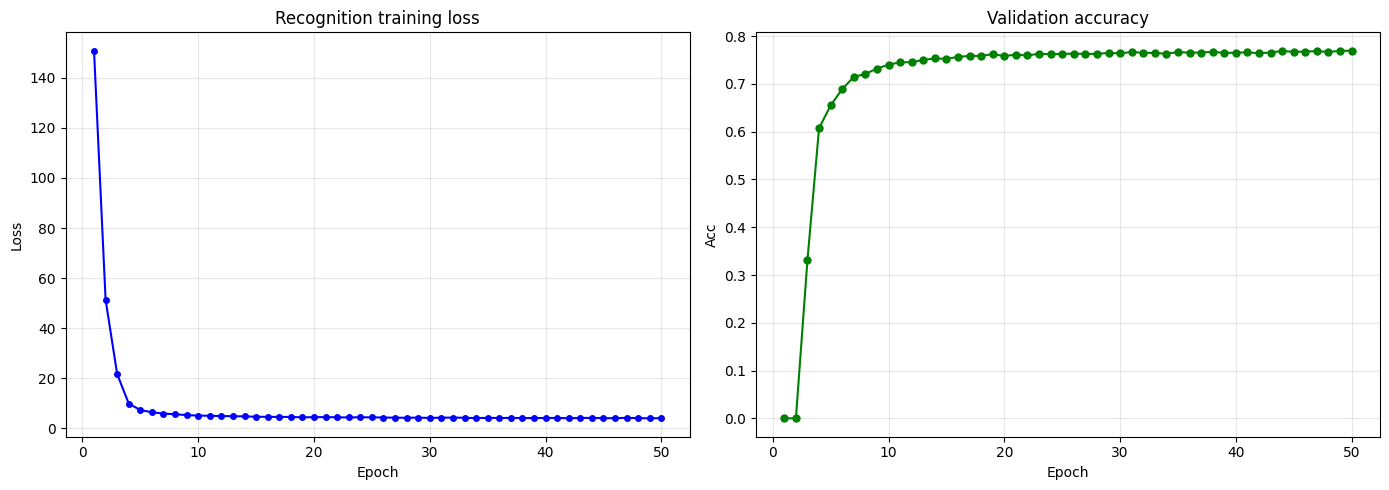

Curves saved → /kaggle/working/ppocrv3_e2e_vintext/rec_training_curves.png


In [19]:
# ============================================================
# Cell 10 — Parse training log + plot curves  (by EPOCH)

import matplotlib.pyplot as plt
import re, os

def parse_paddle_train_log(log_path: str):
    """
    Parses PaddleOCR log lines and groups loss values by epoch.
    Returns:
      epoch_numbers  – list of epoch ints (one per loss entry)
      train_losses   – corresponding loss values
      val_epochs     – epoch at which each validation was run
      val_accs       – corresponding accuracy values
    Handles both log formats:
      [2024/xx/xx ...] epoch: [3/100], iter: [200/430], loss: 1.234, ...
      epoch:[3/100] global_step:600 loss:1.234
      cur metric, acc: 0.6543, norm_edit_dis: ...
    """
    epoch_numbers = []
    train_losses  = []
    val_epochs    = []
    val_accs      = []
    last_epoch    = 0          # track latest epoch seen for val lines

    if not os.path.isfile(log_path):
        print(f"  Log not found: {log_path}")
        return epoch_numbers, train_losses, val_epochs, val_accs

    with open(log_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            # ── Training loss line ──────────────────────────────────────
            if ("loss" in line) and ("epoch" in line) and ("iter" in line or "global_step" in line):
                try:
                    m_epoch = re.search(r"epoch[:\s\[]+(\d+)", line)
                    m_loss  = re.search(r"loss[:\s]+([0-9]+\.[0-9]+)", line)
                    if m_epoch and m_loss:
                        ep = int(m_epoch.group(1))
                        last_epoch = ep
                        epoch_numbers.append(ep)
                        train_losses.append(float(m_loss.group(1)))
                except Exception:
                    pass

            # ── Validation accuracy line ────────────────────────────────
            if "acc" in line and ("cur metric" in line or "eval" in line.lower()):
                try:
                    m_acc = re.search(r"acc[:\s]+([0-9]+\.[0-9]+)", line)
                    if m_acc:
                        val_epochs.append(last_epoch)
                        val_accs.append(float(m_acc.group(1)))
                except Exception:
                    pass

    return epoch_numbers, train_losses, val_epochs, val_accs


train_log = os.path.join(REC_SAVE_DIR, "train.log")
print(f"Reading: {train_log}")

if os.path.isfile(train_log):
    with open(train_log, encoding="utf-8", errors="replace") as f:
        lines = f.readlines()
    print(f"  Total lines: {len(lines)}")
    print("  First 10 lines:")
    for l in lines[:10]:
        print("   ", l.rstrip())
else:
    print(" train.log not found")
    lines = []

epoch_numbers, train_losses, val_epochs, val_accs = parse_paddle_train_log(train_log)
print(f"\n  Parsed: {len(train_losses)} loss entries, {len(val_accs)} val-acc entries")

# ── Average loss per epoch for a clean curve ────────────────────────────────
from collections import defaultdict
import numpy as np

epoch_loss_map = defaultdict(list)
for ep, loss in zip(epoch_numbers, train_losses):
    epoch_loss_map[ep].append(loss)

sorted_epochs   = sorted(epoch_loss_map.keys())
avg_loss_epochs = sorted_epochs
avg_losses      = [np.mean(epoch_loss_map[ep]) for ep in sorted_epochs]

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def smart_ticks(epochs, max_ticks=15):
    """Return at most max_ticks evenly-spaced epoch values."""
    epochs = sorted(set(epochs))
    if len(epochs) <= max_ticks:
        return epochs
    step = max(1, len(epochs) // max_ticks)
    ticks = epochs[::step]
    if epochs[-1] not in ticks:          # always include the last epoch
        ticks.append(epochs[-1])
    return ticks

if avg_losses:
    axes[0].plot(avg_loss_epochs, avg_losses, "b-o", ms=4, lw=1.5)
    axes[0].set_title("Recognition training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_xticks(range(0, max(avg_loss_epochs) + 1, 10))
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5,
                 "No loss entries found.\nCheck printed log lines above\nto see actual format.",
                 ha="center", va="center", fontsize=10)
    axes[0].set_axis_off()

if val_accs:
    axes[1].plot(val_epochs, val_accs, "g-o", ms=5, lw=1.5)
    axes[1].set_title("Validation accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Acc")
    axes[1].set_xticks(range(0, max(val_epochs) + 1, 10))
    axes[1].grid(True, alpha=0.3)
    best_idx = int(np.argmax(val_accs))
else:
    axes[1].text(0.5, 0.5, "No val acc entries found.", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
curves_path = os.path.join(OUT_DIR, "rec_training_curves.png")
plt.savefig(curves_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Curves saved → {curves_path}")

In [15]:
# ============================================================
# Cell 11 - Build final E2E pipeline from fixed export
# ============================================================
pipeline, RECOGNIZER = build_pipeline_from_export(REC_INFER_DIR)
print("E2E pipeline ready")


[2026/06/26 07:32:20] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
E2E pipeline ready


In [16]:
# ============================================================
# Cell 12 - Final evaluation (val + test)
# ============================================================
final_results = print_e2e_results(
    pipeline,
    title="FINAL PADDLEOCR E2E SCENE TEXT SPOTTING SUMMARY",
    eval_test=True,
)
for tag, res in final_results.items():
    with open(os.path.join(OUT_DIR, f"e2e_metrics_{tag.lower()}.json"), "w") as f:
        json.dump(res, f, indent=2)

print("\n" + "=" * 88)
print("  FINAL SUMMARY TABLE")
print("=" * 88)
print(f"  {'Split':<14} {'Det P':>7} {'Det R':>7} {'Det H':>7}   "
      f"{'E2E P':>7} {'E2E R':>7} {'E2E H':>7}   {'CER':>7} {'WER':>7}")
print("  " + "-" * 80)
for tag, r in final_results.items():
    print(f"  {tag:<14} "
          f"{r['det_precision']:>7.4f} {r['det_recall']:>7.4f} {r['det_hmean']:>7.4f}   "
          f"{r['precision']:>7.4f} {r['recall']:>7.4f} {r['hmean']:>7.4f}   "
          f"{r['cer']:>7.4f} {r['wer']:>7.4f}")
print("=" * 88)



  FINAL PADDLEOCR E2E SCENE TEXT SPOTTING SUMMARY

--- Validation ---


E2E [val_image]: 100%|██████████| 300/300 [00:49<00:00,  6.04it/s]


  Detection-only (IoU>=0.5): P=0.7413  R=0.4803  H-mean=0.5830
  End-to-end  (det + recog): P=0.5720  R=0.4163  H-mean=0.4819
  Recognition (IoU-matched): CER=0.0751  WER=0.2288  (n=3459)
  Counts -- E2E TP=2669 FP=1997 FN=3742  (over 300 images)

--- Test ---


E2E [test_image]: 100%|██████████| 500/500 [01:14<00:00,  6.67it/s]

  Detection-only (IoU>=0.5): P=0.7637  R=0.5381  H-mean=0.6314
  End-to-end  (det + recog): P=0.5809  R=0.4698  H-mean=0.5194
  Recognition (IoU-matched): CER=0.0826  WER=0.2403  (n=5417)
  Counts -- E2E TP=4120 FP=2973 FN=4650  (over 500 images)

  FINAL SUMMARY TABLE
  Split            Det P   Det R   Det H     E2E P   E2E R   E2E H       CER     WER
  --------------------------------------------------------------------------------
  Validation      0.7413  0.4803  0.5830    0.5720  0.4163  0.4819    0.0751  0.2288
  Test            0.7637  0.5381  0.6314    0.5809  0.4698  0.5194    0.0826  0.2403


In [20]:
# ============================================================
# Cell 14 ? Save trained recognition model bundle (.pth + portable zip)
# ============================================================

import os, json, shutil, zipfile
from pathlib import Path

import numpy as np
import paddle
import torch

MODEL_BUNDLE_DIR = os.path.join(OUT_DIR, "saved_recognition_model")
os.makedirs(MODEL_BUNDLE_DIR, exist_ok=True)


def _first_existing_checkpoint_stem():
    candidates = [
        os.path.join(REC_SAVE_DIR, "best_accuracy"),
        os.path.join(REC_SAVE_DIR, "latest"),
        os.path.join(REC_SAVE_DIR, f"iter_epoch_{REC_NUM_EPOCHS}"),
    ]
    # Also search any iter_epoch_* checkpoints if Paddle saved one manually.
    if os.path.isdir(REC_SAVE_DIR):
        for name in sorted(os.listdir(REC_SAVE_DIR), reverse=True):
            if name.startswith("iter_epoch_"):
                candidates.append(os.path.join(REC_SAVE_DIR, name))
    for stem in candidates:
        if os.path.exists(stem + ".pdparams"):
            return stem
    return None


REC_CKPT_STEM = _first_existing_checkpoint_stem()
if REC_CKPT_STEM is None:
    raise FileNotFoundError(
        f"No trained recognition checkpoint found under {REC_SAVE_DIR}. "
        "Expected best_accuracy.pdparams or latest.pdparams. "
        "Run the recognition training cell first."
    )

print(f"Using recognition checkpoint: {REC_CKPT_STEM}.pdparams")

# Re-export inference with the same character dictionary used during training.
# This prevents the Failed-2 bug where exported class count/dictionary order mismatched training.
exported_rec_dir = export_rec_inference(REC_CKPT_STEM, REC_INFER_DIR)
print(f"Exported recognizer inference dir: {exported_rec_dir}")

# Save a .pth bundle for easy download/storage. This is a container for Paddle weights,
# not a directly loadable PyTorch model architecture.
paddle_state = paddle.load(REC_CKPT_STEM + ".pdparams")
torch_state = {}
for key, value in paddle_state.items():
    arr = value.numpy() if hasattr(value, "numpy") else np.asarray(value)
    torch_state[key] = torch.from_numpy(arr)

with open(DICT_PATH, encoding="utf-8") as f:
    character_dict_text = f.read()
with open(REC_CONFIG_PATH, encoding="utf-8") as f:
    rec_config_text = f.read()

pth_path = os.path.join(MODEL_BUNDLE_DIR, "ppocrv3_mobile_rec_vintext_50epochs.pth")
torch.save({
    "framework": "paddleocr_recognition_weights_saved_in_torch_container",
    "source_checkpoint_stem": REC_CKPT_STEM,
    "rec_num_epochs": REC_NUM_EPOCHS,
    "character_dict_path": DICT_PATH,
    "character_dict_text": character_dict_text,
    "rec_config_path": REC_CONFIG_PATH,
    "rec_config_text": rec_config_text,
    "state_dict": torch_state,
}, pth_path)
print(f"Saved .pth bundle -> {pth_path}")

# Copy raw Paddle checkpoint pieces and exported inference graph into a portable folder.
paddle_bundle_dir = os.path.join(MODEL_BUNDLE_DIR, "paddle_files")
os.makedirs(paddle_bundle_dir, exist_ok=True)
for ext in [".pdparams", ".pdopt", ".states"]:
    src = REC_CKPT_STEM + ext
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(paddle_bundle_dir, "recognizer" + ext))

for src in [DICT_PATH, REC_CONFIG_PATH]:
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(paddle_bundle_dir, os.path.basename(src)))

if exported_rec_dir and os.path.isdir(exported_rec_dir):
    dst_infer = os.path.join(paddle_bundle_dir, "inference")
    if os.path.isdir(dst_infer):
        shutil.rmtree(dst_infer)
    shutil.copytree(exported_rec_dir, dst_infer)

manifest = {
    "checkpoint_stem": REC_CKPT_STEM,
    "pth_bundle": pth_path,
    "paddle_bundle_dir": paddle_bundle_dir,
    "dict_path": DICT_PATH,
    "config_path": REC_CONFIG_PATH,
    "inference_dir": exported_rec_dir,
    "note": "Use paddle_files/ for PaddleOCR inference or fine-tuning. The .pth is an archival torch-save container for Paddle weights.",
}
manifest_path = os.path.join(MODEL_BUNDLE_DIR, "manifest.json")
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

zip_path = os.path.join(MODEL_BUNDLE_DIR, "ppocrv3_mobile_rec_vintext_12epochs_paddle_bundle.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(paddle_bundle_dir):
        for name in files:
            fp = os.path.join(root, name)
            zf.write(fp, os.path.relpath(fp, MODEL_BUNDLE_DIR))
    zf.write(manifest_path, os.path.basename(manifest_path))

print(f"Saved PaddleOCR portable bundle -> {zip_path}")
print("\nDownload these from Kaggle output:")
print(" -", pth_path)
print(" -", zip_path)


Using recognition checkpoint: /kaggle/working/ppocrv3_e2e_vintext/rec_train/best_accuracy.pdparams

[E2E] Exporting recognizer with matching dictionary...
/usr/bin/python3 /kaggle/working/PaddleOCR/tools/export_model.py -c /kaggle/working/ppocrv3_e2e_vintext/latin_rec_vintext.yml -o Global.pretrained_model=/kaggle/working/ppocrv3_e2e_vintext/rec_train/best_accuracy Global.save_inference_dir=/kaggle/working/ppocrv3_e2e_vintext/rec_inference Global.use_gpu=true Global.character_dict_path=/kaggle/working/ppocrv3_e2e_vintext/vintext_latin_dict.txt Global.use_space_char=true Global.max_text_length=25


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
W0626 07:44:51.080381 83536 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0626 07:44:51.081806 83536 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Skipping import of the encryption module.
[2026/06/26 07:44:51] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_e2e_vintext/rec_train/best_accuracy
[2026/06/26 07:44:51] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.yml
Skipping import of the encryption module
[2026/06/26 07:44:52] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference
[E2E] Recognition graph: /kaggle/working/ppocrv3_e2e_vintext/rec_inference/inference.json
Exported recognizer inference dir: /kaggle/working/ppocrv3_e2e_vintext/rec_inference
Saved .pth bundle -> /kaggle/working/ppocrv3_e2e_vintext/saved_recognition_model/ppocrv3_mobile_rec_vintext_50epochs.pth
Saved PaddleOCR portable bundle -> /kaggle/working/ppocrv3_e2e_vintext/saved_recognition_model/ppocrv3_mobile_rec_vintext_12epochs_paddle_bundle.zip

Download these from Kaggle output:
 - /kaggle/working/ppocrv3_e2e_vintext/saved_recognition_mod